## Business Context

An investment team oversees portfolios belonging to clients with different risk profiles. Each portfolio contains a combination of equities, bonds and cash, with exposures across multiple sectors and geographic regions.

The team wants to better understand the overall structure of the portfolios and identify potential areas of interest for portfolio review.

The analysis focuses on four dimensions:

- asset allocation,
- geographic and sector exposure,
- differences between client profiles,
- portfolio concentration.


## Data

The dataset contains position-level information for multiple client portfolios.

| Field | Description |
| --- | --- |
| `portfolio_id` | Portfolio identifier |
| `client_profile` | Client investment profile |
| `instrument` | Financial instrument |
| `asset_class` | Equity, bond or cash |
| `sector` | Economic sector or instrument category |
| `region` | Geographic exposure |
| `market_value` | Current value of the position |
| `performance_ytd` | Year-to-date instrument performance |

The first step is to load the data and perform an initial review of its structure.


## Data Overview

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

portfolio = pd.read_csv("portfolio_data.csv")


In [5]:
print(portfolio.shape)
portfolio.info()
portfolio.head()

(191, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   portfolio_id     191 non-null    object 
 1   client_profile   191 non-null    object 
 2   instrument       191 non-null    object 
 3   asset_class      191 non-null    object 
 4   sector           191 non-null    object 
 5   region           191 non-null    object 
 6   market_value     191 non-null    int64  
 7   performance_ytd  191 non-null    float64
dtypes: float64(1), int64(1), object(6)
memory usage: 12.1+ KB


,portfolio_id,client_profile,instrument,asset_class,sector,region,market_value,performance_ytd
0,P019,Conservative,Euro Gov Bond 2029,Bond,Government,Europe,52900,0.0511
1,P016,Growth,Nestle,Equity,Consumer Staples,Europe,90400,0.0892
2,P012,Balanced,Novo Nordisk,Equity,Healthcare,Europe,47500,0.2190
3,P006,Growth,Eli Lilly,Equity,Healthcare,North America,98400,0.2762
4,P009,Balanced,Investment Grade Corp EUR,Bond,Corporate,Europe,130600,0.0448


## 1. Asset Allocation

Start by examining the aggregate allocation of the portfolios.

Determine how total market value is distributed across asset classes and identify the dominant asset class. Present the allocation in a clear visualization.

This provides a first high-level view of how the assets in the dataset are invested.


In [7]:
asset_classes_mkt_value = portfolio.groupby('asset_class')['market_value'].sum()

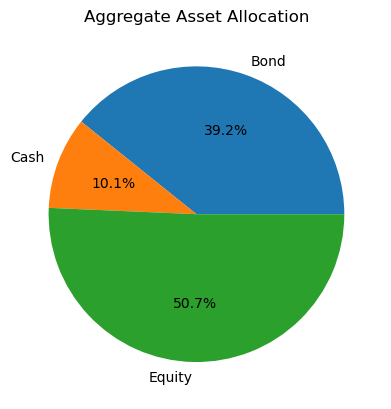

In [8]:
plt.pie(
    asset_classes_mkt_value, 
    labels=asset_classes_mkt_value.index,
    autopct='%1.1f%%'
)
plt.title("Aggregate Asset Allocation")
plt.show()

## 2. Geographic and Sector Exposure

Move beyond asset classes to examine where the portfolios are invested.

Focus first on the **equity allocation** and determine which geographic region represents the largest share of total equity exposure.

Then analyze sector exposure across the dataset and identify the **three sectors with the highest aggregate market value**.

Consider what these results reveal about the main sources of exposure in the portfolios.


In [10]:
asset_class_region = round((portfolio.groupby(['asset_class', 'region'])['market_value'].sum() / portfolio.groupby('asset_class')['market_value'].sum())*100, 2)
equity_region = asset_class_region['Equity']
highest_equity_share = equity_region[equity_region == equity_region.max()]
dt_highest_equity_share = {
    "Region": highest_equity_share.index[0],
    "Weight": highest_equity_share.values[0]
}
print(dt_highest_equity_share)

{'Region': 'Europe', 'Weight': 43.9}


In [11]:
sector_market_value = portfolio.groupby('sector')['market_value'].sum().sort_values(ascending=False)
df_sector_market_value = pd.DataFrame(sector_market_value)
highest_sector = df_sector_market_value.iloc[0:3]
dt_sector_market_value = {}
for i in range(len(highest_sector)):
    dt_sector_market_value[highest_sector.index[i]] = highest_sector.values[i][0]
print(dt_sector_market_value)

{'Government': 4310800, 'Corporate': 2675700, 'Technology': 2219800}


## 3. Client Profile Analysis

The portfolios belong to clients with different investment profiles.

Compare the portfolios across these profiles and determine which profile has, on average, the **highest proportion of equities**.

The analysis should be based on portfolio weights rather than simply counting the number of equity positions.


In [9]:
portfolio_profile = round((portfolio[portfolio['asset_class']=='Equity'].groupby(['portfolio_id', 'client_profile'])['market_value'].sum() / portfolio.groupby(['portfolio_id', 'client_profile'])['market_value'].sum())*100, 2)
aggregated_data = round(portfolio_profile.groupby('client_profile').agg('mean'), 2)
print(aggregated_data)

client_profile
Balanced        49.38
Conservative    24.08
Growth          70.95
Name: market_value, dtype: float64


## 4. Holdings Across Portfolios

Some securities may be used repeatedly across different client portfolios.

Identify the instruments that are held in **more than one portfolio** and explore which holdings appear most frequently.

This analysis can help reveal common building blocks used across the portfolio set.


In [16]:
instrument_counts = portfolio['instrument'].value_counts()
print(instrument_counts[instrument_counts>1])

instrument
Emerging Market Bond         12
USD Cash                     12
Euro Gov Bond 2032           11
European High Yield          10
US Treasury 2030             10
Investment Grade Corp USD    10
Investment Grade Corp EUR    10
Novo Nordisk                 10
Sony                          9
Coca-Cola                     9
LVMH                          8
EUR Cash                      8
Allianz                       7
US Treasury 2033              7
Siemens                       7
Microsoft                     5
Alphabet                      5
Visa                          5
NVIDIA                        4
Euro Gov Bond 2029            4
Nestle                        4
Eli Lilly                     4
Samsung Electronics           4
ASML                          3
Toyota                        3
TSMC                          2
Schneider Electric            2
Apple                         2
SAP                           2
JPMorgan Chase                2
Name: count, dtype: int64


## 5. Portfolio Concentration

Position size is an important dimension of portfolio monitoring.

Calculate the weight of each position relative to the total market value of its portfolio. Use these weights to identify the portfolio with the **largest single-position exposure**.

Explore the result and consider whether some portfolios appear more concentrated than others.


In [18]:
portfolio_instrument_weight = round((portfolio.groupby(['portfolio_id', 'instrument'])['market_value'].sum() / portfolio.groupby('portfolio_id')['market_value'].sum())*100, 2)
df_portfolio_instrument_weight = pd.DataFrame(portfolio_instrument_weight)
largest_single_position_exposure = df_portfolio_instrument_weight[df_portfolio_instrument_weight['market_value'] == df_portfolio_instrument_weight['market_value'].max()]
dt_largest_position = {
    "Portfolio": largest_single_position_exposure.index[0][0],
    "Instrument": largest_single_position_exposure.index[0][1],
    "Weight": largest_single_position_exposure.values[0][0]
}
print(dt_largest_position)

{'Portfolio': 'P007', 'Instrument': 'Emerging Market Bond', 'Weight': 24.69}


## Conclusion

* The analysis highlights a predominantly equity-oriented portfolio set, with Europe representing the largest regional exposure within equities.
* The three sectors with the highest aggregate market value are government, corporate and technology.
* Growth has, on average, the highest proportion of equities.
* Finally, P007 has the largest single-position exposure with Emerging Market Bond representing 24.69% of the portfolio.